# TIR Analysis

Analysis of time in range (TIR) across MDI, Pump and HCL treatment groups. The workflow progresses from data preparation and descriptive analysis to causal estimation using DoWhy regression, multinomial propensity-score inverse probability weighting (IPW), and a Random Forest propensity model.

**Notebook map:** 1) Setup and import → 2) Cleaning and reshaping → 3) Descriptive analysis → 4) DoWhy causal analysis → 5) IPW → 6) Random Forest propensity model.

> **Reproducibility:** after placing `filled_TIR_dataset.xlsx` in the same working directory, restart the kernel and run all cells from top to bottom before submission.

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn import linear_model
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
import ipywidgets as widgets
from matplotlib.lines import Line2D

from dowhy import CausalModel
from dowhy.causal_estimators.linear_regression_estimator import LinearRegressionEstimator

## 2. Data import

Load the source worksheet, remove unused columns, and separate patient characteristics from longitudinal TIR measurements.

In [2]:
df = pd.read_excel("filled_TIR_dataset.xlsx", sheet_name="Sheet4", skiprows=1)

df = df.drop(["Unnamed: 0", "Unnamed: 1", "Unnamed: 2",  "Unnamed: 3"], axis=1)

In [3]:
# dividing the dataframe into  2 with iloc indexing 
df_patient_char=df.iloc[0:5]
df_patient_char=df_patient_char.set_index("Patient")

df_patient_vals=df.iloc[7:]

print(len(df_patient_vals))
print(len(df_patient_vals.columns))

33
180


## 3. Data cleaning and reshaping

Patient characteristics and TIR measurements are cleaned separately before being recombined into long format.

### 3.1 Patient characteristics

In [4]:
# if all values are null, drop the row
df_patient_char= df_patient_char.dropna(axis=1, how='all')
# df_patient_char contains ( Patient number, Age, Treatment, Ethnicity, Social Deprivation and Risk. )
df_patient_char

,1,2,3,4,5,6,7,8,9,10,...,161,162,163,164,165,166,167,168,169,170
Patient,,,,,,,,,,,,,,,,,,,,,
MDI/Pump/HCL,MDI,MDI,HCL,pump,pump,MDI,MDI,MDI,MDI,pump,...,pump,MDI,MDI,HCL,pump,HCL,pump,MDI,MDI,HCL
High risk/ low risk,High risk,High risk,low risk,high risk,low risk,High risk,low risk,low risk,high risk,high risk,...,low risk,low risk,low risk,low risk,low risk,low risk,low risk,low risk,low risk,high risk
Social deprivation,2,2,3,2,5,3,3,9,3,4,...,4,2,1,1,3,10,3,2,2,3
age,20,25,25,26,21,25,22,23,26,21,...,22,25,21,22,23,22,26,23,24,27
ethnicity,black,black,white,black,white,asian,white,white,white,white,...,black,other,black,white,white,white,white,black,black,black


### 3.2 TIR measurements

Inspect the measurement columns, identify text entries, convert those entries to missing values, and remove completely empty patient columns.

In [5]:
list(df_patient_vals.columns)

# Setting the Patient column as the dataframe index
df_patient_vals = df_patient_vals.reset_index().copy().set_index("Patient")

#  storing all text values and their counts in this dictionary 
all_text_values = {}

for col in df_patient_vals.columns:
    for index, row in df_patient_vals.iterrows():
        if isinstance(row[col], str):
            if row[col] in all_text_values:
                all_text_values[row[col]] += 1  
            else:
                all_text_values[row[col]] = 1  
all_text_values

# replacing all text values with NaN
df_patient_vals=df_patient_vals.replace(list(all_text_values.keys()), np.nan)

# if all values are missing then delete the patient 
df_patient_vals= df_patient_vals.dropna(axis=1, how='all')

df_patient_vals.isna().sum()

/opt/anaconda3/lib/python3.13/site-packages/pandas/core/indexes/base.py:7588: FutureWarning: Dtype inference on a pandas object (Series, Index, ExtensionArray) is deprecated. The Index constructor will keep the original dtype in the future. Call `infer_objects` on the result to get the old behavior.
  return Index(sequences[0], name=names)
/var/folders/8p/x_3c3bpd4xnfmt67869t9cd80000gn/T/ipykernel_97728/707098564.py:19: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_patient_vals=df_patient_vals.replace(list(all_text_values.keys()), np.nan)


index     0
1        15
4        20
5         4
6         9
         ..
165      30
166      29
168       1
169      10
170       7
Length: 145, dtype: int64

### 3.3 Recombine and reshape

The cleaned tables are recombined and reshaped so that each row of `final_df` represents a patient-date TIR observation with patient characteristics attached.

In [6]:
#prepare the "complete" dataframe by concatening the patient characteristics and patient treatment dataframes

complete = pd.concat([df_patient_char, df_patient_vals], axis=0, join="inner")

print(len(complete.columns))
complete.head(10)

# transposing "complete" df. 
n_meta = 5 

# Rows with info about age,ethnicity, treatment, patient #, risk , social deprivation scores, 
meta = (complete.iloc[:n_meta].T.rename_axis("Patient") .reset_index())

# Date rows
data = complete.iloc[n_meta:].copy()

long_data = (data.rename_axis("date") .reset_index().melt(
        id_vars="date",
        var_name="Patient",
        value_name="TIR"))    # time in range 

# build final dataframe which is the desired dataframe to do all the upcoming analysis on
final_df = long_data.merge(meta, on="Patient", how="left")

final_df.head(10)

# counting the total no of values assigned to each treatment 
print(final_df.groupby("MDI/Pump/HCL").agg(count_equipment=("MDI/Pump/HCL", "count")))

# converting all TIR values to numeric data type. 
final_df["TIR"] = pd.to_numeric(final_df["TIR"], errors="coerce")

144
              count_equipment
MDI/Pump/HCL                 
HCL                      1221
MDI                      2508
pump                     1023


In [7]:
final_df

,date,Patient,TIR,MDI/Pump/HCL,High risk/ low risk,Social deprivation,age,ethnicity
0,2025-04-22,1,NaN,MDI,High risk,2,20,black
1,2025-05-22,1,NaN,MDI,High risk,2,20,black
2,2025-06-22,1,NaN,MDI,High risk,2,20,black
3,2025-07-22,1,NaN,MDI,High risk,2,20,black
4,2025-08-22,1,NaN,MDI,High risk,2,20,black
...,...,...,...,...,...,...,...,...
4747,2024-08-01,170,20.0,HCL,high risk,3,27,black
4748,2024-09-01,170,20.0,HCL,high risk,3,27,black
4749,2024-10-01,170,2.0,HCL,high risk,3,27,black
4750,2024-11-01,170,33.0,HCL,high risk,3,27,black


### 3.4 Patient entry dates

For each patient, derive the first and last dates with a non-missing TIR observation.

In [8]:
# adding a column for every patient's  first and last TIR entry dates 

valid_dates = ( final_df[final_df["TIR"].notna()]
    .groupby("Patient")["date"]
    .agg(first_entry_date="min", last_entry_date="max"))

final_df = final_df.merge(valid_dates, on="Patient", how="left")

final_df.head()

,date,Patient,TIR,MDI/Pump/HCL,High risk/ low risk,Social deprivation,age,ethnicity,first_entry_date,last_entry_date
0,2025-04-22,1,NaN,MDI,High risk,2,20,black,2023-01-01,2024-12-01
1,2025-05-22,1,NaN,MDI,High risk,2,20,black,2023-01-01,2024-12-01
2,2025-06-22,1,NaN,MDI,High risk,2,20,black,2023-01-01,2024-12-01
3,2025-07-22,1,NaN,MDI,High risk,2,20,black,2023-01-01,2024-12-01
4,2025-08-22,1,NaN,MDI,High risk,2,20,black,2023-01-01,2024-12-01


## 4. Descriptive analysis

Summarise observed TIR distributions, achievement of the 70% target, and changes in TIR across observed months.

### 4.1 Distribution of TIR readings by treatment

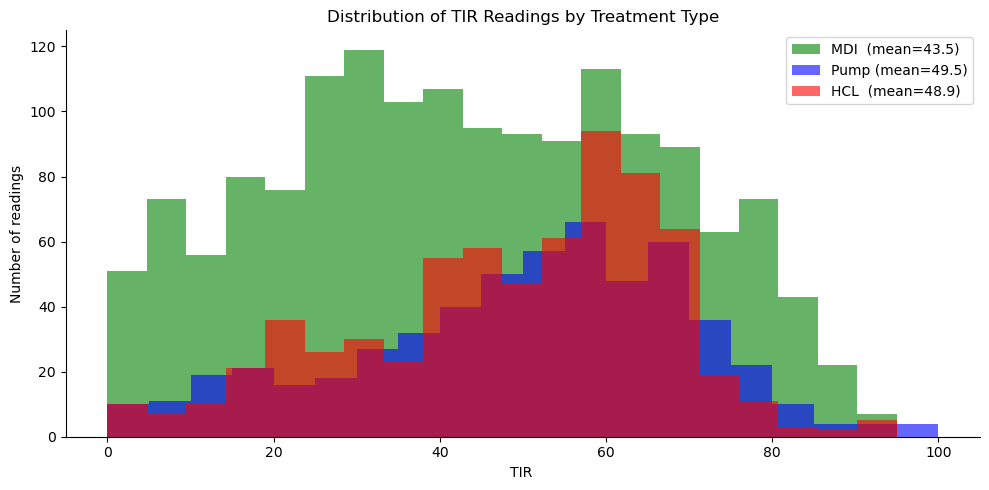

In [9]:
# Calculating per treatment TIR entry 
density_plot = True
mdi_vals  = final_df[final_df['MDI/Pump/HCL'] == 'MDI']['TIR']
pump_vals = final_df[final_df['MDI/Pump/HCL'] == 'pump']['TIR'].dropna()
hcl_vals  = final_df[final_df['MDI/Pump/HCL'] == 'HCL']['TIR'].dropna()

fig, ax = plt.subplots(figsize=(10, 5))

# Plot overlapping histograms
ax.hist(mdi_vals,  bins=20, color="green", alpha=0.6, label=f'MDI  (mean={round(mdi_vals.mean(),1)})')
ax.hist(pump_vals, bins=20, color="blue", alpha=0.6, label=f'Pump (mean={round(pump_vals.mean(),1)})')
ax.hist(hcl_vals,  bins=20, color="red", alpha=0.6, label=f'HCL  (mean={round(hcl_vals.mean(),1)})')


ax.set_xlabel('TIR ')
ax.set_ylabel('Number of readings')
ax.set_title('Distribution of TIR Readings by Treatment Type')
ax.legend()
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

### 4.2 Achievement of mean TIR ≥ 70%

Calculate patient-level mean TIR within treatment group and summarise the percentage reaching the 70% threshold.

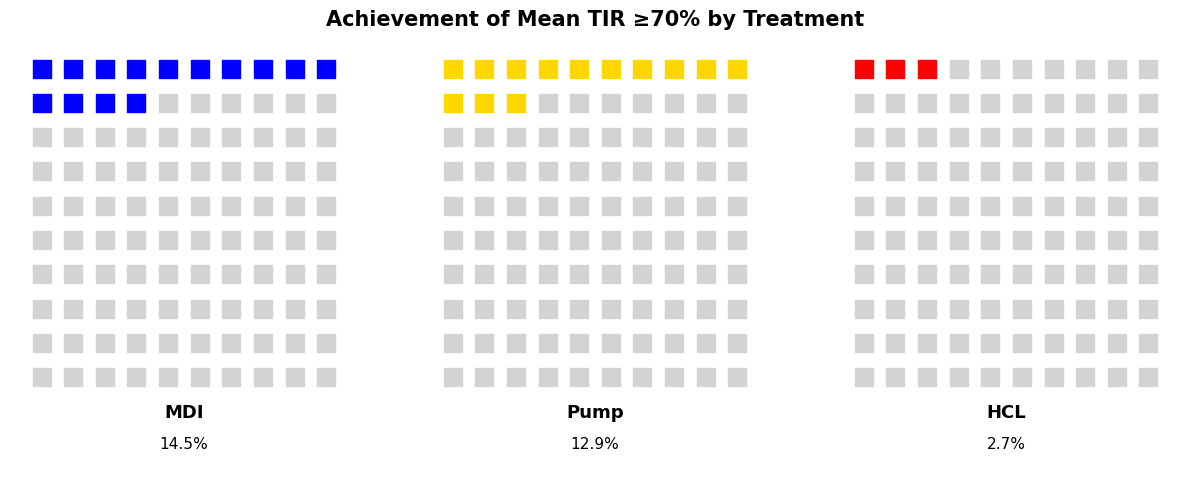

In [10]:
# calculate mean TIR for each patient and treatment

performance_df = (final_df.dropna(subset=["TIR"])
    .groupby(["Patient", "MDI/Pump/HCL"], as_index=False)["TIR"]
    .mean())

performance_df = performance_df.rename(columns={"MDI/Pump/HCL": "treatment", "TIR": "mean_TIR"})

performance_df["treatment"] = performance_df["treatment"].replace({"pump": "Pump"})

# percentage of patient-treatment records with mean TIR >= 70

target_pct = ( performance_df.groupby("treatment")["mean_TIR"]
    .apply(lambda x: (x >= 70).mean() * 100)
    .reindex(["MDI", "Pump", "HCL"]))

treatments = ["MDI", "Pump", "HCL"]
colors = ["blue", "gold", "red"]

fig, ax = plt.subplots(figsize=(12, 5))

for group in range(3):

    percentage = target_pct.iloc[group]
    filled = round(percentage)

    for i in range(100):
        row = i // 10
        column = i % 10

        x = column + (group * 13)
        y = 9 - row

        if i < filled:
            color = colors[group]
        else:
            color = "lightgrey"

        ax.scatter(x, y, marker="s", s=180, color=color)

    ax.text(4.5 + (group * 13),
        -1.2,
        treatments[group],
        ha="center",
        fontsize=13,
        fontweight="bold")

    ax.text(4.5 + (group * 13),
        -2.1,
        f"{percentage:.1f}%",
        ha="center",
        fontsize=11)

ax.set_title("Achievement of Mean TIR ≥70% by Treatment", fontsize=15, fontweight="bold")
ax.set_xlim(-1, 36)
ax.set_ylim(-3, 10)
ax.axis("off")

plt.tight_layout()
plt.show()

### 4.3 TIR over time

#### Prepare the monthly time index

In [11]:
# analysing TIR changes month on month

df_time = final_df[["date", "MDI/Pump/HCL", "TIR"]].copy()

df_time = df_time.rename(columns={"MDI/Pump/HCL": "treatment"})
df_time["treatment"] = df_time["treatment"].replace({"pump": "Pump"})

df_time["date"] = pd.to_datetime(df_time["date"])
df_time["TIR"] = pd.to_numeric(df_time["TIR"], errors="coerce")

df_time = df_time.dropna(subset=["date", "treatment", "TIR"])

df_time["month"] = df_time["date"].dt.to_period("M").dt.to_timestamp()



# first available monitoring month for each treatment group

df_time["first_treatment_month"] = ( df_time.groupby("treatment", observed=True)["month"].transform("min"))


# month 1 = first observed calendar month for that treatment group

df_time["month_number"] = (
    (df_time["month"].dt.year - df_time["first_treatment_month"].dt.year) * 12
    + (df_time["month"].dt.month - df_time["first_treatment_month"].dt.month)+ 1).astype(int)

print("Rows available for time trend:", len(df_time))

print( df_time[["month", "first_treatment_month", "month_number", "treatment", "TIR"]].head())

Rows available for time trend: 2776
        month first_treatment_month  month_number treatment   TIR
9  2023-01-01            2023-01-01             1       MDI  24.0
10 2023-02-01            2023-01-01             2       MDI  32.0
11 2023-03-01            2023-01-01             3       MDI  21.0
12 2023-04-01            2023-01-01             4       MDI  20.0
13 2023-05-01            2023-01-01             5       MDI  33.0


#### Summarise monthly TIR and target attainment

In [12]:
# checking whether each TIR reading reached the 70% target

df_time["TIR_70_or_above"] = (df_time["TIR"] >= 70).astype(int)

# summarising TIR for each treatment and month number

time_summary = (
    df_time.groupby(["month_number", "treatment"], observed=True)
    .agg(
        average_TIR=("TIR", "mean"),
        total_readings=("TIR", "count"),
        readings_70_or_above=("TIR_70_or_above", "sum"),
        pct_70_or_above=("TIR_70_or_above", "mean")).reset_index())

# converting the proportion to a percentage

time_summary["pct_70_or_above"] = (
    time_summary["pct_70_or_above"] * 100)

time_summary = time_summary.round(1)

display(time_summary)

,month_number,treatment,average_TIR,total_readings,readings_70_or_above,pct_70_or_above
0,1,HCL,47.2,16,0,0.0
1,1,MDI,40.4,46,6,13.0
2,1,Pump,46.3,21,2,9.5
3,2,HCL,44.2,15,0,0.0
4,2,MDI,41.2,49,6,12.2
...,...,...,...,...,...,...
94,35,MDI,42.0,35,5,14.3
95,35,Pump,47.9,17,0,0.0
96,36,HCL,43.3,13,1,7.7
97,36,MDI,41.5,40,5,12.5


#### Plot average TIR by month since first observation

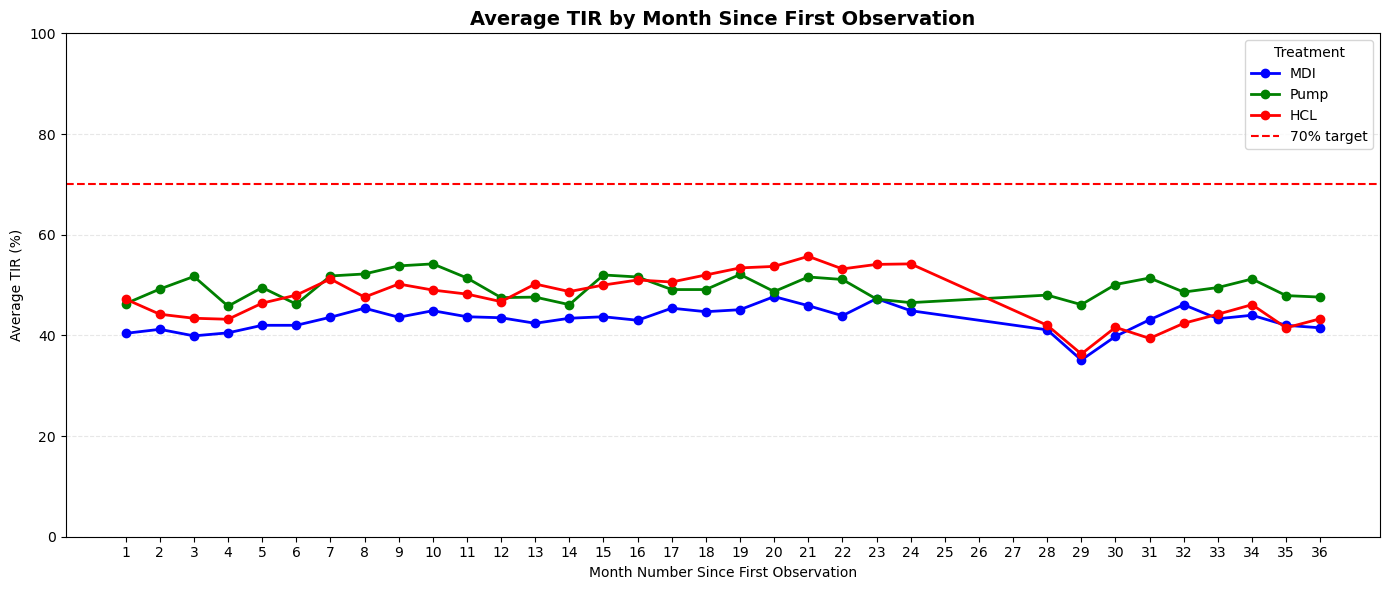

In [13]:
colors = {"MDI": "blue",
    "Pump": "green",
    "HCL": "red"}

plt.figure(figsize=(14, 6))

for treatment in ["MDI", "Pump", "HCL"]:

    treatment_data = ( time_summary[time_summary["treatment"] == treatment].sort_values("month_number"))

    if not treatment_data.empty:
        plt.plot(
            treatment_data["month_number"],
            treatment_data["average_TIR"],
            marker="o",
            linewidth=2,
            label=treatment,
            color=colors[treatment])

plt.axhline(y=70,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label="70% target")

plt.title("Average TIR by Month Since First Observation",
    fontsize=14,
    fontweight="bold")

plt.xlabel("Month Number Since First Observation")
plt.ylabel("Average TIR (%)")
plt.ylim(0, 100)

if not time_summary.empty:
    maximum_month = int(time_summary["month_number"].max())
    plt.xticks(range(1, maximum_month + 1))

plt.legend(title="Treatment")
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Causal analysis with DoWhy

The causal analysis uses a patient-level outcome. Variables are standardised, longitudinal TIR values are reduced to a patient-level mean, and causal assumptions are encoded in a directed acyclic graph (DAG).

### 5.1 Validate causal-analysis variables

Standardise names and categorical values, convert numeric variables, and check that the expected treatment labels are present.

In [14]:
# creating a pseudo df
analysis_df = final_df[["date",
     "Patient",
     "TIR",
     "MDI/Pump/HCL",
     "High risk/ low risk",
     "Social deprivation",
     "age ",
     "ethnicity " ]].copy()

# Remove leading/trailing spaces from column names such as "age " and "ethnicity ".
analysis_df.columns = analysis_df.columns.str.strip()

# Rename columns to simple names that work cleanly in the DAG and regression formula.
analysis_df = analysis_df.rename(columns={ "MDI/Pump/HCL": "treatment",
    "High risk/ low risk": "risk",
    "Social deprivation": "deprivation"})

# Confirm that every required source column exists before continuing.
required_source_columns = ["date", 
    "Patient",
    "TIR",
    "treatment",
    "risk",
    "deprivation",
    "age",
    "ethnicity"] 

missing_columns = [column for column in required_source_columns if column not in analysis_df.columns]
if missing_columns:
    raise KeyError(f"Required columns are missing: {missing_columns}")

In [15]:
# Keeping only the variables needed for the causal analysis.
analysis_df = analysis_df[required_source_columns].copy()

# All Patient IDs are converted to strings 
analysis_df["Patient"] = (analysis_df["Patient"]
    .astype("string")
    .str.strip())

# Standardised categorical values so spelling and capitalisation do not create false categories.
for column in ["treatment", "risk", "ethnicity"]:
    analysis_df[column] = (analysis_df[column]
        .astype("string")
        .str.strip()
        .str.lower())

# Convert quantitative variables to numeric values for multi-variate regression
# Invalid text is converted to missing and removed below.

for column in ["TIR", "age", "deprivation"]: 
    analysis_df[column] = pd.to_numeric( analysis_df[column],errors="coerce")

# Check that treatment contains only the three expected groups.
expected_treatments = {"mdi", "pump", "hcl"}
unexpected_treatments = sorted(set(analysis_df["treatment"].dropna().unique()) - expected_treatments)
if unexpected_treatments:
    raise ValueError( f"Unexpected treatment labels found: {unexpected_treatments}")

# Removing rows that cannot be used by the upcoming regression.
# In this dataset the main loss is from missing numeric TIR values.
required_model_columns = ["Patient",
    "TIR",
    "treatment",
    "risk",
    "deprivation",
    "age",
    "ethnicity"]

rows_before = len(analysis_df)
analysis_df = (analysis_df.dropna(subset=required_model_columns).reset_index(drop=True))

# Converting the patient IDs to ordinary Python strings 
analysis_df["Patient"] = analysis_df["Patient"].astype(str)

analysis_df.head()

,date,Patient,TIR,treatment,risk,deprivation,age,ethnicity
0,2023-01-01,1,24.0,mdi,high risk,2,20,black
1,2023-02-01,1,32.0,mdi,high risk,2,20,black
2,2023-03-01,1,21.0,mdi,high risk,2,20,black
3,2023-04-01,1,20.0,mdi,high risk,2,20,black
4,2023-05-01,1,33.0,mdi,high risk,2,20,black


### 5.2 Build the patient-level analysis dataset

Transpose the patient-characteristics table so that each row represents one patient, standardise covariates, calculate mean TIR per patient, and merge the components.

In [16]:

# Transpose the patient-characteristics table
patient_df = df_patient_char.transpose()

# Patient identifiers are currently in the index
patient_df.index.name = "Patient"
patient_df = patient_df.reset_index()

# Remove the optional name attached to the column axis
patient_df.columns.name = None

# Clean column names
patient_df.columns = (
    patient_df.columns
    .astype(str)
    .str.strip())

# Rename columns
patient_df = patient_df.rename(columns={
        "MDI/Pump/HCL": "treatment",
        "High risk/ low risk": "risk",
        "Social deprivation": "deprivation",
        "age": "age",
        "ethnicity": "ethnicity"})

# Clean treatment
patient_df["treatment"] = (
    patient_df["treatment"]
    .astype("string")
    .str.strip()
    .str.lower()
    .replace({
        "mdi": "MDI",
        "pump": "Pump",
        "hcl": "HCL"}))

# Clean risk
patient_df["risk"] = (
    patient_df["risk"]
    .astype("string")
    .str.strip()
    .str.lower()
    .replace({
        "high risk": "High risk",
        "low risk": "Low risk"}))

# Clean ethnicity
patient_df["ethnicity"] = (
    patient_df["ethnicity"]
    .astype("string")
    .str.strip()
    .str.lower())

# Convert numeric variables
patient_df["age"] = pd.to_numeric(patient_df["age"],errors="coerce")

patient_df["deprivation"] = pd.to_numeric(patient_df["deprivation"],errors="coerce")

In [17]:
avg_df= final_df.copy()

avg_df.columns = (
    avg_df.columns
    .astype(str)
    .str.strip())

avg_df.head()

patient_tir = ( avg_df
    .dropna(subset=["TIR"])
    .groupby("Patient", as_index=False)
    .agg(mean_TIR=("TIR", "mean"),
        number_of_TIR_measurements=("TIR", "count")))

patient_tir.head()

# merging patient_tir dataframe with patient_df 

patient_analysis = patient_df.merge(patient_tir,
    on="Patient",
    how="left",
    validate="one_to_one",
    indicator=True)

# left only patients have missing values so deleting them.
patient_analysis=patient_analysis.dropna(axis=0,subset="mean_TIR")
patient_analysis.head()

,Patient,treatment,risk,deprivation,age,ethnicity,mean_TIR,number_of_TIR_measurements,_merge
0,1,MDI,High risk,2,20,black,25.166667,18.0,both
3,4,Pump,High risk,2,26,black,32.538462,13.0,both
4,5,Pump,Low risk,5,21,white,62.448276,29.0,both
5,6,MDI,High risk,3,25,asian,10.166667,24.0,both
6,7,MDI,Low risk,3,22,white,32.774194,31.0,both


### 5.3 Causal graph and identified estimand

The DAG specifies age, ethnicity, deprivation and risk as common causes of treatment and mean TIR. DoWhy identifies the adjustment set implied by these assumptions.

Identified Estimand: Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
     d                                                  
────────────(E[mean_TIR|age,risk,ethnicity,deprivation])
d[treatment]                                            
Estimand assumption 1, Unconfoundedness: If U→{treatment} and U→mean_TIR then P(mean_TIR|treatment,age,risk,ethnicity,deprivation,U) = P(mean_TIR|treatment,age,risk,ethnicity,deprivation)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
     d                                                  
────────────(E[mean_TIR|age,risk,ethnicity,deprivation])
d[treatment]                                            
Estimand assumption 1, Unconfoundedness: If U→{treatment} and U→mean_TIR then P(mean_TIR|treatment,age,risk,ethnicity,deprivation,U) =

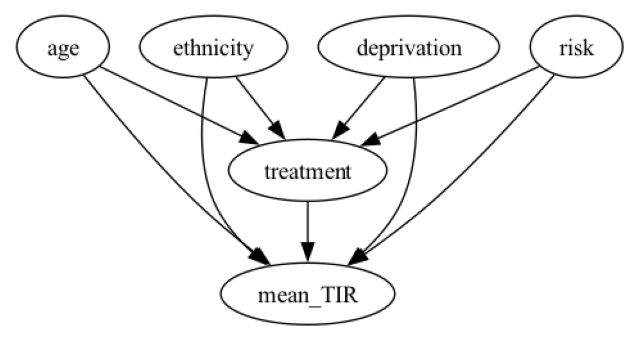

In [18]:

# defining the causal assumptions for Graphviz to use while building the DAG. Graphviz can read strings and interpret them 
causal_graph = """digraph {
    age -> treatment;
    age -> mean_TIR;

    ethnicity -> treatment;
    ethnicity -> mean_TIR;

    deprivation -> treatment;
    deprivation -> mean_TIR;

    risk -> treatment;
    risk -> mean_TIR;

    treatment -> mean_TIR}"""


#  plotting the model 

causal_model = CausalModel(data=patient_analysis,
    treatment="treatment",
    outcome="mean_TIR",
    graph=causal_graph)

# identifying the adjustment set( Backdoor or front door paths ) and the estimand and whether ATE can be identified from this data 
identified_estimand = causal_model.identify_effect(method_name="default")

print(f'Identified Estimand: {identified_estimand}')


#  dispalying the DAG 

causal_model.view_model(file_name="diabetes_causal_dag")

# In DoWhy, a backdoor path is a non-causal route between the treatment and outcome that can create a misleading association.

### 5.4 Linear-regression treatment-effect estimates

Fit the DoWhy linear-regression estimator and calculate all three pairwise treatment contrasts with bootstrap confidence intervals.

In [19]:

# preparing the regression model 

regression_estimator = LinearRegressionEstimator(
    identified_estimand=identified_estimand,
    test_significance=False,
    confidence_intervals="bootstrap",
    # DoWhy's official source documentation recommends a 95 % confidence interval
    confidence_level=0.95,
    # The default number of simulations to obtain confidence intervals
    # This should be at least 399 for a 5% error rate: https://www.econstor.eu/bitstream/10419/67820/1/587473266.pdf
    # In each bootstrap simulation, DoWhy resamples patient_analysis df, refits the estimator, re-estimates the same treatment contrast, 
    # and stores that causal-effect estimate. It then uses the distribution of those repeated estimates to construct the interval.
    num_simulations=399,
    need_conditional_estimates=False).fit(
    data=patient_analysis,
    effect_modifier_names=[])

In [20]:
#  fitting the regression to the 3 treatment comparisons 


comparisons = [("Pump vs MDI", "MDI", "Pump"),
    ("HCL vs MDI", "MDI", "HCL"),
    ("HCL vs Pump", "Pump", "HCL")]

results = []

for comparison, control, treatment in comparisons:

    estimate = regression_estimator.estimate_effect(
        data=patient_analysis,
        control_value=control,
        treatment_value=treatment,
        target_units="ate",
        confidence_intervals=True,
        need_conditional_estimates=False)

    confidence_interval = estimate.get_confidence_intervals(method="bootstrap")

    print(comparison)
    print(estimate)

    results.append({ "comparison": comparison,
        "control": control,
        "treatment": treatment,
        "ate": estimate.value,
        "ci_lower": confidence_interval[0],
        "ci_upper": confidence_interval[1]})

Pump vs MDI
*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

## Realized estimand
b: mean_TIR~treatment+age+risk+ethnicity+deprivation
Target units: ate

## Estimate
Mean value: 3.9700199950448294
95.0% confidence interval: (np.float64(-5.290022961220693), np.float64(13.112165341768936))

HCL vs MDI
*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

## Realized estimand
b: mean_TIR~treatment+age+risk+ethnicity+deprivation
Target units: ate

## Estimate
Mean value: 5.39076290146204
95.0% confidence interval: (np.float64(-2.448537148386272), np.float64(15.953651154603357))

HCL vs Pump
*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

## Realized estimand
b: mean_TIR~treatment+age+risk+ethnicity+deprivation
Target units: ate

## Estimate
Mean value: 1.4207429064172103
95.0% confidence interval: (np.float64(-10.388577138475931), np.float64(8.01361116451369

In [21]:
# average estimated treatment effect
causal_results = pd.DataFrame(results)

# calculating how far the confidence intervals extend
causal_results["lower_error"] = (causal_results["ate"] - causal_results["ci_lower"])

causal_results["upper_error"] = (causal_results["ci_upper"] - causal_results["ate"])

causal_results

,comparison,control,treatment,ate,ci_lower,ci_upper,lower_error,upper_error
0,Pump vs MDI,MDI,Pump,3.970020,-5.290023,13.112165,9.260043,9.142145
1,HCL vs MDI,MDI,HCL,5.390763,-2.448537,15.953651,7.839300,10.562888
2,HCL vs Pump,Pump,HCL,1.420743,-10.388577,8.013611,11.809320,6.592868


In [22]:
# causal estimates for plotting that are already calculated above. 

results = causal_results.copy()
results

# lowwr and upper error are for matplotlib to draw the confidence interval line from the esimate.

,comparison,control,treatment,ate,ci_lower,ci_upper,lower_error,upper_error
0,Pump vs MDI,MDI,Pump,3.970020,-5.290023,13.112165,9.260043,9.142145
1,HCL vs MDI,MDI,HCL,5.390763,-2.448537,15.953651,7.839300,10.562888
2,HCL vs Pump,Pump,HCL,1.420743,-10.388577,8.013611,11.809320,6.592868


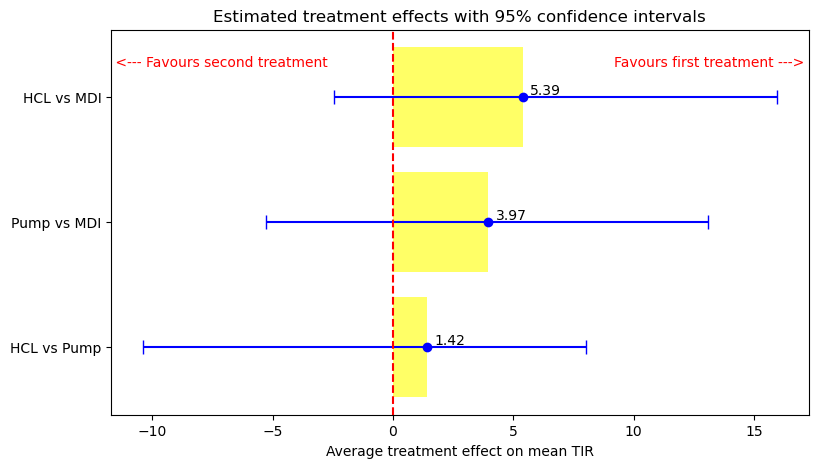

In [23]:
# graphical representation of the results of the regression

# sorting the results according to the treatment effect
results = results.sort_values("ate")

fig, ax = plt.subplots(figsize=(9, 5))

# horizontal bars showing the average treatment effect
ax.barh(results["comparison"], results["ate"], alpha=0.6, color="yellow")

# showing the 95% confidence intervals
ax.errorbar(results["ate"], results["comparison"],
            xerr=[results["lower_error"], results["upper_error"]],
            fmt="o", capsize=5, color="blue")

# zero represents no treatment effect
ax.axvline(0, linestyle="--", color="red")

# adding the treatment effect value to each comparison
for i, row in results.iterrows():
    ax.text(row["ate"] + 0.3, row["comparison"],f"{row['ate']:.2f}", va="bottom")

# adding interpretation to the graph
xmin, xmax = ax.get_xlim()

ax.text(xmax, len(results) - 0.75,
        "Favours first treatment ---> ", ha="right", color="red")

ax.text(xmin, len(results) - 0.75,
        " <--- Favours second treatment", ha="left", color="red")

ax.set_xlabel("Average treatment effect on mean TIR")
ax.set_ylabel("")
ax.set_title("Estimated treatment effects with 95% confidence intervals")

plt.show()

**Reading the effect plot:** an ATE of 0 is the no-effect reference. The interval shown for each treatment comparison is the 95% confidence interval.

## 6. Inverse probability weighting

A multinomial propensity model estimates the probability of MDI, Pump or HCL conditional on the DoWhy adjustment set. These probabilities are converted to inverse probability weights and used to estimate treatment effects in a weighted pseudo-population.

### 6.1 Prepare the propensity-score dataset

In [24]:
# Modelling the multi-nomial propensity score model to obtain probablities of MDI, PUMP 
# and HCL treatments for every patient . 

# obtaining the adjustment set identified that was identified by DoWhy in the identified estimand. 
confounders = list(identified_estimand.get_adjustment_set())

print("Confounders identified by DoWhy: ")
print(confounders)

# keeping a separate dataframe for the IPW analysis
randomising_df = patient_analysis.copy()

# checking the three treatment groups
print("\nTreatment counts:")
print(randomising_df["treatment"].value_counts())

# checking for missing values in the confounders
print("\nMissing values:")
print(randomising_df[confounders].isna().sum())

Confounders identified by DoWhy: 
['age', 'risk', 'ethnicity', 'deprivation']

Treatment counts:
treatment
MDI     76
HCL     37
Pump    31
Name: count, dtype: Int64

Missing values:
age            0
risk           0
ethnicity      0
deprivation    0
dtype: int64


### 6.2 Encode confounders and fit the multinomial model

In [25]:
encoding=sklearn.preprocessing.OneHotEncoder(categories='auto',
                                            drop=None,
                                            sparse_output=True,
                                            dtype= np.float64, 
                                            handle_unknown='error',
                                            min_frequency=None,
                                            max_categories=None,
                                            feature_name_combiner='concat')

encoded_var=randomising_df[["ethnicity", "risk"]]
encoded_X = encoding.fit_transform(encoded_var)
encoding.get_feature_names_out(["ethnicity", "risk"])


#  converting the encoded variables into a df so that I can merge it with the remaining variables and utilise for inverse probability weighting 
encoded_df = pd.DataFrame( encoded_X.toarray(),
    columns=encoding.get_feature_names_out(["ethnicity", "risk"]),
    index=randomising_df.index)

encoded_df.head()

numerical_df = randomising_df[["age", "deprivation"]].copy()

all_encoded_var=pd.concat([numerical_df,encoded_df],axis=1)


all_encoded_var.head()

# creating a multinomial regression model for the treatment 
y = randomising_df["treatment"]

random_propensity = sklearn.linear_model.LogisticRegression(penalty='deprecated',
                                                            C=1.0,
                                                            l1_ratio=0.0,
                                                            dual=False,
                                                            tol=0.0001,
                                                            fit_intercept=True,
                                                            intercept_scaling=1,
                                                            class_weight=None,
                                                            random_state=None,
                                                            solver='lbfgs',
                                                            max_iter=1000,
                                                            verbose=0,
                                                            warm_start=False,
                                                            n_jobs=None)


random_propensity.fit(all_encoded_var, y) #estimates treatment assignment from the four confounders.

prob_x = random_propensity.predict_proba(all_encoded_var)
# through this I will get 3 propensity scores for each patient for each treatment 
print("The following propensities are displayed in the following order of treatment :\n" ,random_propensity.classes_)
prob_x[:5]

The following propensities are displayed in the following order of treatment :
 ['HCL' 'MDI' 'Pump']


array([[0.24307626, 0.59847946, 0.15844428],
       [0.17420469, 0.5205784 , 0.30521691],
       [0.30501522, 0.53233734, 0.16264744],
       [0.19385207, 0.54538815, 0.26075979],
       [0.29774051, 0.48408159, 0.2181779 ]])

The multinomial logistic model estimates each patient's probability of receiving MDI, Pump or HCL based on age, risk level, social deprivation score and ethnicity.

#### Optional diagnostic: individual patient propensity profile

In [26]:
colours={"HCL":"red",
         "MDI":"yellow",
         "Pump":"green"}
def show_patient(patient):

    patient_info = randomising_df[randomising_df["Patient"] == patient].iloc[0]

    patient_position = randomising_df["Patient"].tolist().index(patient)

    probs = prob_x[patient_position]

    treatments = random_propensity.classes_
    actual = patient_info["treatment"]

    explode = [0.08 if treatment == actual
                else 0 
                for treatment in treatments]

    labels = [ f"{treatment}\n{probability:.1%}"
        for treatment, probability in zip(treatments, probs)]

    plt.figure(figsize=(8, 6))

    plt.pie(
        probs,
        labels=labels,
        colors=[colours[treatment] for treatment in treatments],
        explode=explode,
        startangle=90,
        labeldistance=0.80,
        textprops={
            "fontsize": 10,
            "ha": "center"},
        wedgeprops={
            "width": 0.4,
            "edgecolor": "white"})

    plt.text(
        0,
        0.08,
        "Actual treatment",
        ha="center",
        fontsize=10)

    plt.text(
        0,
        -0.10,
        actual,
        ha="center",
        fontsize=16,
        fontweight="bold")

    plt.title(f"Treatment Propensity Profile - Patient {patient}")

    plt.show()

patient_dropdown = widgets.Dropdown(
    options=randomising_df["Patient"].tolist(),
    description="Patient:")

widgets.interact(show_patient,patient=patient_dropdown)

interactive(children=(Dropdown(description='Patient:', options=(1, 4, 5, 6, 7, 8, 9, 10, '11_A', '11_B', 12, 1…

<function __main__.show_patient(patient)>

### 6.3 Construct inverse probability weights

Match each patient to the propensity score for the treatment actually received, take its inverse, and inspect the resulting weight range.

In [27]:
# adding propensity weights for each patient and each of the treatments 

propensity_df = pd.DataFrame(prob_x,columns=[
        f"p({treatment})"
        for treatment in random_propensity.classes_],
    index=randomising_df.index)

randomising_df = pd.concat(
    [randomising_df.drop(columns=["_merge"]), propensity_df],
    axis=1)

randomising_df.head()

# creating inverse probability wieghts for each patient for the specific treatment they recieved . 

# matching the patient's specific treatment to propensity score column. 
type_of_treatment = [
    randomising_df["treatment"] == "HCL",
    randomising_df["treatment"] == "MDI",
    randomising_df["treatment"] == "Pump"]
# mapping the treatment once its decided to its relative probability 
probabilities = [ randomising_df["p(HCL)"],
                randomising_df["p(MDI)"],
                randomising_df["p(Pump)"]]

# using numpy select to chose values based in type of treatment and probabilities 
randomising_df["propensity_actual_treatment"] = np.select(type_of_treatment,probabilities )

randomising_df[["treatment", "p(HCL)", "p(MDI)", "p(Pump)", "propensity_actual_treatment"]].head()

# creating a column for inverse probability weighting  
# calculating the inverse probability weights
randomising_df["IPW"] = 1 / randomising_df["propensity_actual_treatment"]
randomising_df[["treatment", "propensity_actual_treatment", "IPW"]].head()

randomising_df.head()

# checking for any probabilities that are close to zero 
randomising_df["IPW"].describe()

print("Lowest actual propensity score:",randomising_df["propensity_actual_treatment"].min())
print("Highest IPW:",randomising_df["IPW"].max())

Lowest actual propensity score: 0.14237474171291428
Highest IPW: 7.023717746343021


### 6.4 Assess covariate balance

Standardised mean differences (SMDs) are calculated pairwise across treatment groups before and after weighting. For each confounder, the maximum absolute pairwise SMD is retained.

#### Define SMD functions

In [28]:
# treatment comparisons
treatment_pairs = [
    ("MDI", "Pump"),
    ("MDI", "HCL"),
    ("Pump", "HCL")]

# calculating the standardised mean difference
def calculate_smd(values, treatment_1, treatment_2, weighted=False):

    group_1 = randomising_df["treatment"] == treatment_1
    group_2 = randomising_df["treatment"] == treatment_2

    values_1 = values[group_1]
    values_2 = values[group_2]

    if weighted:

        weights_1 = randomising_df.loc[group_1, "IPW"]
        weights_2 = randomising_df.loc[group_2, "IPW"]

        mean_1 = np.average(values_1, weights=weights_1)
        mean_2 = np.average(values_2, weights=weights_2)

        variance_1 = np.average((values_1 - mean_1) ** 2, weights=weights_1)

        variance_2 = np.average((values_2 - mean_2) ** 2,weights=weights_2)

    else:

        mean_1 = values_1.mean()
        mean_2 = values_2.mean()

        variance_1 = values_1.var(ddof=0)
        variance_2 = values_2.var(ddof=0)

    pooled_sd = np.sqrt((variance_1 + variance_2) / 2)

    if pooled_sd == 0:
        return 0

    return abs( (mean_1 - mean_2) / pooled_sd)


# get the largest difference between treatment groups
def maximum_smd(values, weighted=False):

    smd_values = []

    for treatment_1, treatment_2 in treatment_pairs:

        smd_values.append(calculate_smd(values,
                treatment_1,
                treatment_2,
                weighted))

    return max(smd_values)

#### Calculate and report balance before and after IPW

In [29]:
# age
age_before = maximum_smd(randomising_df["age"],weighted=False)

age_after = maximum_smd( randomising_df["age"],weighted=True)


# deprivation
deprivation_before = maximum_smd(randomising_df["deprivation"], weighted=False)

deprivation_after = maximum_smd( randomising_df["deprivation"],weighted=True)


# risk
risk_values = (randomising_df["risk"] == "High risk").astype(int)

risk_before = maximum_smd(risk_values,weighted=False)

risk_after = maximum_smd(risk_values,weighted=True)


# ethnicity
ethnicity_before = 0
ethnicity_after = 0

for ethnicity in randomising_df["ethnicity"].unique():

    ethnicity_values = (randomising_df["ethnicity"] == ethnicity).astype(int)

    before = maximum_smd( ethnicity_values,weighted=False)

    after = maximum_smd(ethnicity_values,weighted=True)

    ethnicity_before = max(ethnicity_before,before)

    ethnicity_after = max(ethnicity_after,after)

confounders = [ "Age",
    "Deprivation",
    "Risk",
    "Ethnicity"]

before_ipw = [ age_before,
    deprivation_before,
    risk_before,
    ethnicity_before]

after_ipw = [age_after,
    deprivation_after,
    risk_after,
    ethnicity_after]

for confounder, before, after in zip(  confounders, before_ipw, after_ipw):

    print(confounder,"| Before IPW:",round(before, 3),"| After IPW:",round(after, 3))

Age | Before IPW: 0.328 | After IPW: 0.077
Deprivation | Before IPW: 0.244 | After IPW: 0.015
Risk | Before IPW: 0.22 | After IPW: 0.053
Ethnicity | Before IPW: 0.378 | After IPW: 0.137


#### Love plot

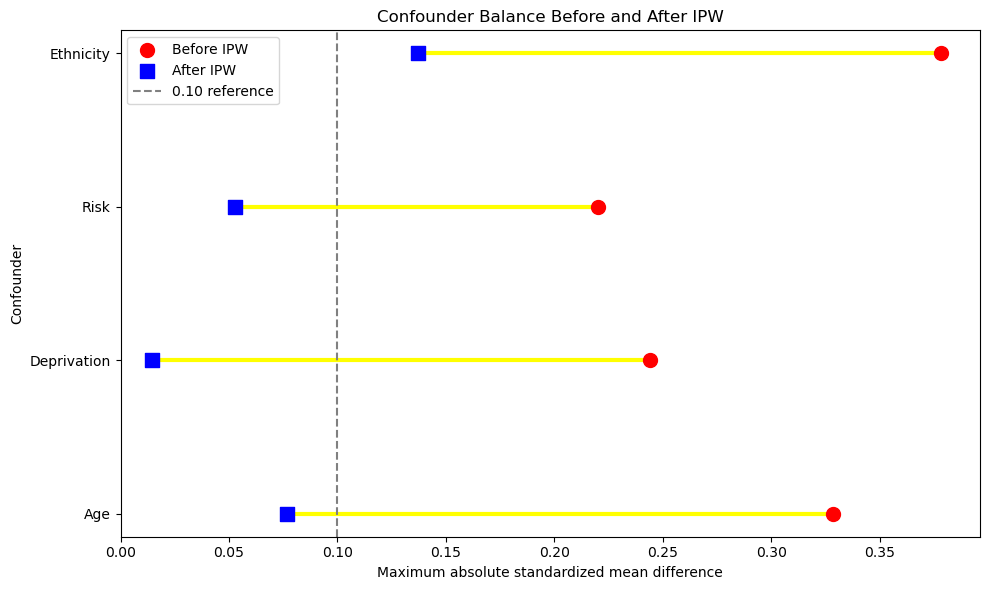

In [30]:
# love plot

y_position = np.arange(len(confounders))

fig, ax = plt.subplots(figsize=(10, 6))

for y, before, after in zip( y_position,before_ipw,after_ipw):

    ax.hlines(y=y,
        xmin=min(before, after),
        xmax=max(before, after),
        color="yellow",
        linewidth=3)

ax.scatter(before_ipw,
    y_position,
    color="red",
    s=100,
    label="Before IPW",
    zorder=3)

ax.scatter(after_ipw,
    y_position,
    color="blue",
    marker="s",
    s=100,
    label="After IPW",
    zorder=3)

ax.axvline( x=0.1,
    color="grey",
    linestyle="--",
    linewidth=1.5,
    label="0.10 reference")

ax.set_yticks(y_position)
ax.set_yticklabels(confounders)

ax.set_xlabel("Maximum absolute standardized mean difference")
ax.set_ylabel("Confounder")
ax.set_title("Confounder Balance Before and After IPW")

ax.set_xlim(left=0)
ax.legend()

plt.tight_layout()
plt.show()

#### Distribution of inverse probability weights

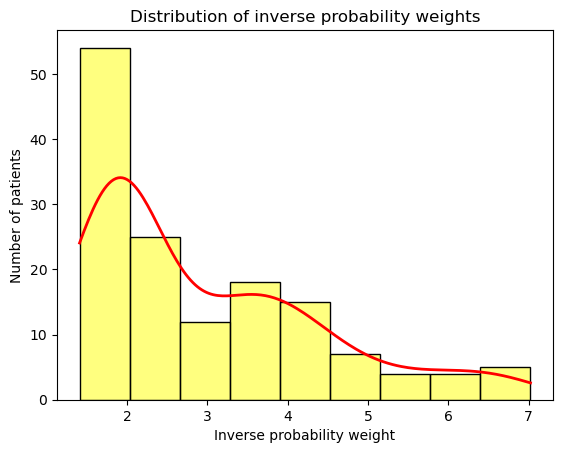

In [31]:
ax = sns.histplot(
    data=randomising_df,
    x="IPW",
    color="yellow",
    kde=True
)

# change the KDE line to red
ax.lines[0].set_color("red")
ax.lines[0].set_linewidth(2)

plt.xlabel("Inverse probability weight")
plt.ylabel("Number of patients")
plt.title("Distribution of inverse probability weights")

plt.show()

### 6.5 Estimate treatment effects in the IPW pseudo-population

One-hot encode treatment with MDI as the reference group, then fit a weighted linear regression using the inverse probability weights.

In [32]:
# encode treatment into two variables, with MDI as the reference
treatment_encoding = OneHotEncoder(
    categories=[["MDI", "Pump", "HCL"]],
    drop="first",
    sparse_output=False)

treatment_X = treatment_encoding.fit_transform(
    randomising_df[["treatment"]])

treatment_encoding.get_feature_names_out(["treatment"])

y = randomising_df["mean_TIR"]
weighted_regression = sklearn.linear_model.LinearRegression()

weighted_regression.fit(treatment_X,y,sample_weight=randomising_df["IPW"])
# this sample weight is where the IPW is taken into consideration 
pump_vs_mdi = weighted_regression.coef_[0]
hcl_vs_mdi = weighted_regression.coef_[1]

hcl_vs_pump = hcl_vs_mdi - pump_vs_mdi

print("Regression results from the inverse probability weighted pseudo population:\n")
print("Pump vs MDI:", pump_vs_mdi)
print("HCL vs MDI:", hcl_vs_mdi)
print("HCL vs Pump:", hcl_vs_pump)

Regression results from the inverse probability weighted pseudo population:

Pump vs MDI: 4.815978908846894
HCL vs MDI: 4.863712365116261
HCL vs Pump: 0.0477334562693672


### 6.6 Bootstrap confidence intervals

Resample patients, refit the propensity model, reconstruct the IPW weights, and re-estimate treatment effects in each bootstrap sample.

In [33]:
# bootstrap confidence intervals for the IPW estimates


np.random.seed(42)

n_bootstrap = 1000

pump_bootstrap = []
hcl_bootstrap = []
hcl_pump_bootstrap = []


for i in range(n_bootstrap):

    # resample patients
    bootstrap_sample = randomising_df.sample(n=len(randomising_df),replace=True).reset_index(drop=True)

    # in case a treatment group is missing from a sample
    if bootstrap_sample["treatment"].nunique() < 3:
        continue

    # encode ethnicity and risk
    encoded_bootstrap = encoding.transform(bootstrap_sample[["ethnicity", "risk"]])

    encoded_bootstrap_df = pd.DataFrame(encoded_bootstrap.toarray(),columns=encoding.get_feature_names_out(["ethnicity", "risk"]))

    X_bootstrap = pd.concat([bootstrap_sample[["age", "deprivation"]],encoded_bootstrap_df],axis=1)

    # refit the propensity model
    propensity_bootstrap = LogisticRegression(max_iter=1000)

    propensity_bootstrap.fit( X_bootstrap,bootstrap_sample["treatment"])
    

    prob_bootstrap = propensity_bootstrap.predict_proba(X_bootstrap)

    # find the probability of the treatment actually received
    class_positions = {
        treatment: position
        for position, treatment
        in enumerate(propensity_bootstrap.classes_)}

    actual_propensity_bootstrap = np.array([ prob_bootstrap[row, class_positions[treatment]]
        for row, treatment in enumerate(bootstrap_sample["treatment"])])

    ipw_bootstrap = (1 / actual_propensity_bootstrap)

    # encode treatment
    treatment_X_bootstrap = treatment_encoding.transform(bootstrap_sample[["treatment"]])

    # weighted regression
    regression_bootstrap = LinearRegression()

    regression_bootstrap.fit( treatment_X_bootstrap,bootstrap_sample["mean_TIR"],sample_weight=ipw_bootstrap)

    pump_effect = regression_bootstrap.coef_[0]
    hcl_effect = regression_bootstrap.coef_[1]

    pump_bootstrap.append(pump_effect)

    hcl_bootstrap.append(hcl_effect)

    hcl_pump_bootstrap.append(hcl_effect - pump_effect)

In [34]:
# 95% bootstrap confidence intervals
pump_ci = np.percentile(pump_bootstrap,[2.5, 97.5])

hcl_ci = np.percentile( hcl_bootstrap, [2.5, 97.5])

hcl_pump_ci = np.percentile(hcl_pump_bootstrap,[2.5, 97.5])
print("IPW results with 95% bootstrap confidence intervals:\n")

print( "Pump vs MDI:",round(pump_vs_mdi, 3),
    "95% CI:",np.round(pump_ci, 3))

print( "HCL vs MDI:",round(hcl_vs_mdi, 3),
    "95% CI:",np.round(hcl_ci, 3))

print(
    "HCL vs Pump:",round(hcl_vs_pump, 3),
    "95% CI:",np.round(hcl_pump_ci, 3))

IPW results with 95% bootstrap confidence intervals:

Pump vs MDI: 4.816 95% CI: [-3.451 13.396]
HCL vs MDI: 4.864 95% CI: [-2.61  12.056]
HCL vs Pump: 0.048 95% CI: [-9.406  8.9  ]


## 7. Random Forest propensity model

As an alternative propensity specification, fit a Random Forest classifier to the same encoded confounders, convert predicted treatment probabilities to inverse weights, and reuse the weighted outcome model.

### 7.1 Fit the Random Forest propensity model

In [35]:

# separate copy for the Random Forest analysis
rf_df = patient_analysis.copy()

X_rf = all_encoded_var
y_rf = rf_df["treatment"]

# fit Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_rf, y_rf)

# probability of each treatment
rf_probabilities = rf_model.predict_proba(X_rf)

# creating a df for these probabilities
random_forest_prob=pd.DataFrame(rf_probabilities,
                                columns=rf_model.classes_,
                                index=rf_df.index)

random_forest_prob.head()

,HCL,MDI,Pump
0,0.055000,0.855000,0.090000
3,0.037000,0.488667,0.474333
4,0.010000,0.282667,0.707333
5,0.006000,0.529310,0.464690
6,0.155833,0.794167,0.050000


### 7.2 Construct and inspect Random Forest weights

In [36]:
# probability of the treatment actually recieved 
actual_probabilities = []

for i in range(len(rf_df)):

    treatment = rf_df.iloc[i]["treatment"]

    probability = random_forest_prob.iloc[i][treatment]

    actual_probabilities.append(probability)

rf_df["RF_propensity"] = actual_probabilities

# calculate inverse probability weights
rf_df["RF_IPW"] = 1 / rf_df["RF_propensity"]

rf_df[["treatment", "RF_propensity", "RF_IPW"]].head()

# checking random forest weights 
print(rf_df["RF_IPW"].describe())

print("Lowest propensity:",rf_df["RF_propensity"].min())

print("Highest weight:",rf_df["RF_IPW"].max())

count    144.000000
mean       1.668835
std        0.623282
min        1.010101
25%        1.232361
50%        1.402712
75%        2.024637
max        4.028970
Name: RF_IPW, dtype: float64
Lowest propensity: 0.2482023809523809
Highest weight: 4.028970214398773


### 7.3 Estimate weighted treatment effects

In [37]:
# estimating the ATE using random forest weights 
# treatment variables for the weighted regression
rf_treatment = treatment_encoding.transform(
    rf_df[["treatment"]])

# weighted regression
rf_regression = LinearRegression()

rf_regression.fit(rf_treatment,
    rf_df["mean_TIR"],
    sample_weight=rf_df["RF_IPW"])

# treatment effects
rf_pump_mdi = rf_regression.coef_[0]
rf_hcl_mdi = rf_regression.coef_[1]
rf_hcl_pump = rf_hcl_mdi - rf_pump_mdi

print("Pump vs MDI:", round(rf_pump_mdi, 3))
print("HCL vs MDI:", round(rf_hcl_mdi, 3))
print("HCL vs Pump:", round(rf_hcl_pump, 3))

Pump vs MDI: 6.456
HCL vs MDI: 6.26
HCL vs Pump: -0.196


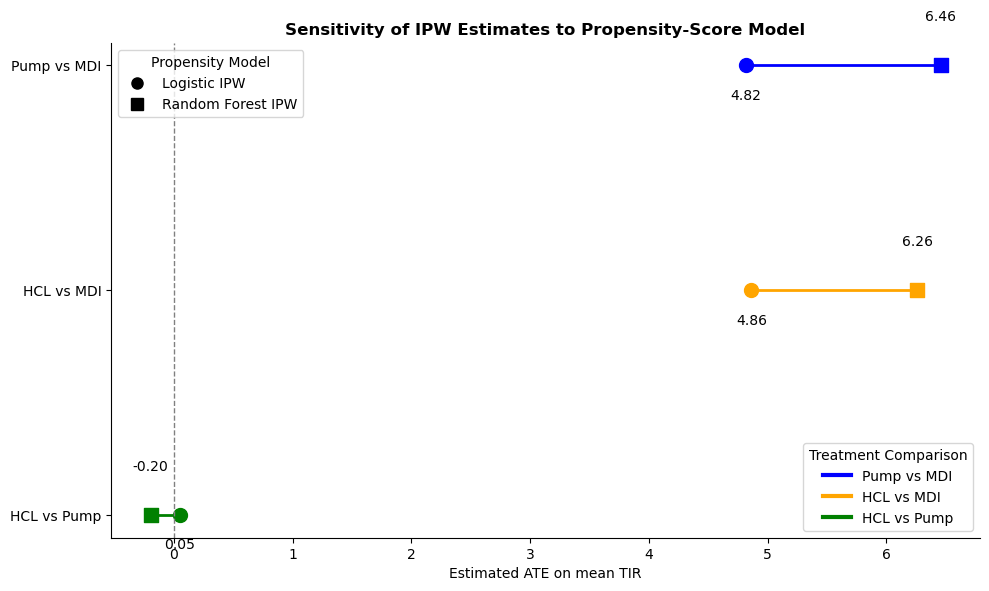

In [38]:

# comparing Logistic IPW with Random Forest IPW

rf_compare = pd.DataFrame({
    "Comparison": [ "Pump vs MDI",
        "HCL vs MDI",
        "HCL vs Pump"],

    "Logistic IPW": [
        pump_vs_mdi,
        hcl_vs_mdi,
        hcl_vs_pump],

    "Random Forest IPW": [
        rf_pump_mdi,
        rf_hcl_mdi,
        rf_hcl_pump]})


# colour for each treatment comparison
comparison_colours = {"Pump vs MDI": "blue",
    "HCL vs MDI": "orange",
    "HCL vs Pump": "green"}


fig, ax = plt.subplots(figsize=(10, 6))


for i in range(len(rf_compare)):

    comparison = rf_compare.loc[i, "Comparison"]
    logistic_value = rf_compare.loc[i, "Logistic IPW"]
    rf_value = rf_compare.loc[i, "Random Forest IPW"]

    colour = comparison_colours[comparison]

    # line connecting the two estimates
    ax.hlines(y=i,
        xmin=min(logistic_value, rf_value),
        xmax=max(logistic_value, rf_value),
        color=colour,
        linewidth=2)

    # Logistic IPW
    ax.scatter(logistic_value,
        i,
        s=100,
        marker="o",
        color=colour)

    # Random Forest IPW
    ax.scatter(rf_value,
        i,
        s=100,
        marker="s",
        color=colour)

    # value labels
    ax.text( logistic_value,
        i + 0.15,
        f"{logistic_value:.2f}",
        ha="center",
        fontsize=10)

    ax.text(rf_value,
        i - 0.20,
        f"{rf_value:.2f}",
        ha="center",
        fontsize=10)


# zero treatment effect reference
ax.axvline(0,
    linestyle="--",
    linewidth=1,
    color="grey")


ax.set_yticks(range(len(rf_compare)))

ax.set_yticklabels(rf_compare["Comparison"])

ax.invert_yaxis()

ax.set_xlabel("Estimated ATE on mean TIR")

ax.set_title("Sensitivity of IPW Estimates to Propensity-Score Model",
    fontweight="bold")


# legend showing the two propensity models
method_legend = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="black",
        linestyle="None",
        markersize=8,
        label="Logistic IPW"),

    Line2D(
        [0],
        [0],
        marker="s",
        color="black",
        linestyle="None",
        markersize=8,
        label="Random Forest IPW")]


# legend showing treatment comparisons
comparison_legend = [
    Line2D(
        [0],
        [0],
        color="blue",
        linewidth=3,
        label="Pump vs MDI"),

    Line2D(
        [0],
        [0],
        color="orange",
        linewidth=3,
        label="HCL vs MDI"),

    Line2D(
        [0],
        [0],
        color="green",
        linewidth=3,
        label="HCL vs Pump")]


# first legend
first_legend = ax.legend(
    handles=method_legend,
    title="Propensity Model",
    loc="upper left",
    frameon=True)

ax.add_artist(first_legend)


# second legend
ax.legend(
    handles=comparison_legend,
    title="Treatment Comparison",
    loc="lower right",
    frameon=True)


ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()